
# Stack RLMT spectra and export a BeSS-compatible FITS file

This notebook:

1. reads multiple one-dimensional RLMT FITS spectra;
2. reconstructs each linear wavelength axis from `CRPIX1`, `CRVAL1`, and `CDELT1`;
3. interpolates the spectra onto their common wavelength overlap;
4. combines them with a mean, median, or sigma-clipped mean;
5. writes a new FITS file containing a clean BeSS-oriented header.

For co-added spectra, the output timing keywords are defined as:

- `DATE-OBS`: start of the first exposure;
- `DATE-END`: end of the last exposure;
- `EXPTIME`: elapsed time from the first start to the last end, as required by the BeSS specification;
- `EXPTIME2`: sum of the individual CCD integration times. This is a useful non-standard supplemental keyword.

The notebook does **not** apply a heliocentric wavelength correction. Therefore `BSS_VHEL = 0.0`. It can calculate `BSS_RQVH`, the correction that would need to be applied.


In [249]:

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.constants import c
from astropy.coordinates import Angle, EarthLocation, SkyCoord
from astropy.io import fits
from astropy.stats import sigma_clip
from astropy.time import Time


## User settings

In [250]:
# import os

# os.listdir('../../../Downloads/2025-11-14_cal/')

In [251]:
target_name = 'lam_eri'
date = '20251114'
# target_name = 'Lam_Eri'
# date = '20260304'

# Files may also be supplied explicitly as a Python list.
# INPUT_GLOB = f"../../../Downloads/2026-03-04_cal/*{target_name}*_1d.fits"
# OUTPUT_FITS = f"../../../Downloads/2026-03-04_cal/{target_name}_{date}.fits"
INPUT_GLOB = f"../../../Downloads/2025-11-14_cal/*{target_name}*_1d.fits"
OUTPUT_FITS = f"../../../Downloads/2025-11-14_cal/{target_name}_{date}.fits"

# BeSS requires at least one author/observer name.
OBSERVER = "Joshua Marine"

# These describe the processing applied to the input spectra.
# For unnormalized pipeline spectra, leave BSS_NORM as "none".
BSS_NORM = "none"
BSS_TELL = "none"
BSS_COSM = "none"

# Combination choices: "mean", "median", or "sigma_clipped_mean".
STACK_METHOD = "sigma_clipped_mean"
SIGMA = 4.0
MAXITERS = 5

# Wavelength grid. None uses the median input dispersion.
OUTPUT_DISPERSION = None

# Optional BeSS resolution metadata. The pipeline SPEC_RES value is a
# typical instrumental resolving power rather than a measured resolution.
INCLUDE_TYPICAL_RESOLUTION = True

# Calculate and include the optional BSS_RQVH keyword.
INCLUDE_BSS_RQVH = True

# If multiple spectra have slightly different target coordinates, use their
# median coordinates after checking that they lie within this tolerance.
COORD_TOLERANCE_ARCSEC = 60.0


## FITS-reading and coordinate helpers

In [252]:

def _as_angle(value, numeric_unit=u.deg):
    """Parse either a sexagesimal string or a numeric angular value."""
    if isinstance(value, str):
        return Angle(value)
    return float(value) * numeric_unit


def _target_coord_from_header(header):
    """Read RLMT TELRA (decimal hours or HMS) and TELDEC (degrees or DMS)."""
    ra_value = header["TELRA"]
    dec_value = header["TELDEC"]

    if isinstance(ra_value, str):
        ra = Angle(ra_value)
    else:
        ra = float(ra_value) * u.hourangle

    dec = _as_angle(dec_value, numeric_unit=u.deg)
    return SkyCoord(ra=ra, dec=dec, frame="icrs")


def _observatory_from_header(header):
    """Construct an EarthLocation from RLMT observatory header cards."""
    lon = _as_angle(header["OBSLONG"], numeric_unit=u.deg)
    lat = _as_angle(header["OBSLAT"], numeric_unit=u.deg)
    height = float(header["OBSELEV"]) * u.m
    return EarthLocation.from_geodetic(lon=lon, lat=lat, height=height)


def _linear_wavelength_axis(header, npix):
    """Reconstruct a FITS linear wavelength axis using one-indexed CRPIX1."""
    crpix = float(header.get("CRPIX1", 1.0))
    crval = float(header["CRVAL1"])
    cdelt = float(header["CDELT1"])
    pixel = np.arange(npix, dtype=float) + 1.0
    return crval + (pixel - crpix) * cdelt


def _read_1d_spectrum(path):
    """Read a primary-HDU one-dimensional spectrum and its metadata."""
    path = Path(path)
    with fits.open(path) as hdul:
        data = np.asarray(hdul[0].data, dtype=float).squeeze()
        header = hdul[0].header.copy()

    if data.ndim != 1:
        raise ValueError(f"{path.name}: expected a 1D primary array, found shape {data.shape}.")

    required = [
        "DATE-OBS", "EXPTIME", "CRVAL1", "CDELT1",
        "TELRA", "TELDEC", "OBSLAT", "OBSLONG", "OBSELEV",
    ]
    missing = [key for key in required if key not in header]
    if missing:
        raise KeyError(f"{path.name}: missing required keyword(s): {', '.join(missing)}")

    wave = _linear_wavelength_axis(header, data.size)
    good = np.isfinite(wave) & np.isfinite(data)
    wave = wave[good]
    flux = data[good]

    order = np.argsort(wave)
    wave = wave[order]
    flux = flux[order]

    start = Time(header["DATE-OBS"], format="isot", scale="utc")
    exptime = float(header["EXPTIME"])
    end = start + exptime * u.s

    return {
        "path": path,
        "header": header,
        "wave": wave,
        "flux": flux,
        "start": start,
        "end": end,
        "exptime": exptime,
        "target_coord": _target_coord_from_header(header),
        "observatory": _observatory_from_header(header),
    }


## Stack the spectra

In [253]:
def stack_spectra(
    paths,
    method="sigma_clipped_mean",
    output_dispersion=None,
    sigma=4.0,
    maxiters=5,
    coord_tolerance_arcsec=60.0,
    wavelength_range = [6200, 7000]
):
    """Read, validate, interpolate, and combine multiple RLMT spectra."""
    paths = [Path(path) for path in paths]
    if not paths:
        raise ValueError("No input spectra were supplied.")

    spectra = [_read_1d_spectrum(path) for path in paths]

    # Keep only the wavelength region covered by every spectrum.
    # wave_min = max(spec["wave"][0] for spec in spectra)
    # wave_max = min(spec["wave"][-1] for spec in spectra)

    wave_min = wavelength_range[0]
    wave_max = wavelength_range[1]
    if wave_max <= wave_min:
        raise ValueError("The input spectra have no common wavelength overlap.")

    if output_dispersion is None:
        dispersions = [np.nanmedian(np.diff(spec["wave"])) for spec in spectra]
        output_dispersion = float(np.nanmedian(dispersions))
    output_dispersion = float(output_dispersion)
    if not np.isfinite(output_dispersion) or output_dispersion <= 0:
        raise ValueError("output_dispersion must be a positive finite number.")

    n_pix = int(np.floor((wave_max - wave_min) / output_dispersion)) + 1
    common_wave = wave_min + np.arange(n_pix, dtype=float) * output_dispersion

    interpolated = np.full((len(spectra), n_pix), np.nan, dtype=float)
    for i, spec in enumerate(spectra):
        interpolated[i] = np.interp(
            common_wave,
            spec["wave"],
            spec["flux"],
            left=np.nan,
            right=np.nan,
        )

    method = method.lower()
    if method == "mean":
        stacked_flux = np.nanmean(interpolated, axis=0)
    elif method == "median":
        stacked_flux = np.nanmedian(interpolated, axis=0)
    elif method == "sigma_clipped_mean":
        clipped = sigma_clip(
            interpolated,
            sigma=float(sigma),
            maxiters=maxiters,
            axis=0,
            masked=True,
        )
        stacked_flux = np.ma.mean(clipped, axis=0).filled(np.nan)
    else:
        raise ValueError("method must be 'mean', 'median', or 'sigma_clipped_mean'.")

    starts = Time([spec["start"] for spec in spectra])
    ends = Time([spec["end"] for spec in spectra])
    first_start = starts[np.argmin(starts.jd)]
    last_end = ends[np.argmax(ends.jd)]

    elapsed_exptime = float((last_end - first_start).to_value(u.s))
    effective_exptime = float(sum(spec["exptime"] for spec in spectra))

    coords = SkyCoord([spec["target_coord"] for spec in spectra])
    reference_coord = coords[0]
    max_separation = np.max(reference_coord.separation(coords).arcsec)
    if max_separation > coord_tolerance_arcsec:
        raise ValueError(
            f"Target coordinates differ by as much as {max_separation:.2f} arcsec, "
            f"exceeding the {coord_tolerance_arcsec:.2f} arcsec tolerance."
        )

    # Circular median is unnecessary here because all coordinates should be close.
    target_coord = SkyCoord(
        ra=np.nanmedian(coords.ra.deg) * u.deg,
        dec=np.nanmedian(coords.dec.deg) * u.deg,
        frame="icrs",
    )

    return {
        "spectra": spectra,
        "wave": common_wave,
        "flux": stacked_flux,
        "interpolated_flux": interpolated,
        "method": method,
        "date_obs": first_start,
        "date_end": last_end,
        "elapsed_exptime": elapsed_exptime,
        "effective_exptime": effective_exptime,
        "target_coord": target_coord,
        "observatory": spectra[0]["observatory"],
        "max_coord_separation_arcsec": float(max_separation),
    }


## Construct the clean BeSS header

In [254]:

def calculate_bss_rqvh(target_coord, observatory, date_obs, date_end):
    """
    Calculate the optional BeSS heliocentric correction-to-be-applied value.

    BeSS defines positive BSS_RQVH as the redshift/escape-velocity convention and
    uses lambda_corrected = lambda_initial * (1 - Vhelio/c). Astropy returns the
    velocity to add to an observed radial velocity; this has the same first-order
    sign as the BeSS correction used in that wavelength equation.
    """
    midpoint = date_obs + 0.5 * (date_end - date_obs)
    midpoint.location = observatory
    correction = target_coord.radial_velocity_correction(
        kind="heliocentric",
        obstime=midpoint,
    )
    return float(correction.to_value(u.km / u.s))


def _common_header_value(spectra, key, default=None):
    """Return a shared value, warning through HISTORY later if values differ."""
    values = [spec["header"].get(key) for spec in spectra]
    present = [value for value in values if value is not None]
    if not present:
        return default
    return present[0]


def make_bess_header(
    stack,
    observer,
    bss_norm="none",
    bss_tell="none",
    bss_cosm="none",
    include_typical_resolution=True,
    include_bss_rqvh=True,
):
    """Create a new header rather than copying internal pipeline metadata."""
    spectra = stack["spectra"]
    source = spectra[0]["header"]
    wave = stack["wave"]

    header = fits.Header()

    # Object identity. BLKNAME is translated to OBJNAME.
    object_name = str(source.get("OBJNAME", source.get("BLKNAME", "UNKNOWN"))).strip()
    header["OBJNAME"] = (object_name, "Object name")
    # header["RA"] = (round(float(stack["target_coord"].ra.deg), 8), "J2000 right ascension [deg]")
    # header["DEC"] = (round(float(stack["target_coord"].dec.deg), 8), "J2000 declination [deg]")
    header["EQUINOX"] = (2000.0, "Coordinate equinox")
    header["RADECSYS"] = ("FK5", "Coordinate reference frame")

    # Acquisition timing.
    header["DATE-OBS"] = (stack["date_obs"].isot, "Start of first exposure [UTC]")
    header["DATE-END"] = (stack["date_end"].isot, "End of last exposure [UTC]")
    header["EXPTIME"] = (
        float(stack["elapsed_exptime"]),
        "First start to last end [s]",
    )
    header["EXPTIME2"] = (
        int(stack["effective_exptime"]),
        "Summed CCD integration time [s]",
    )
    header["NCOMBINE"] = (len(spectra), "Number of combined spectra")

    # Observer and equipment. Existing standard equipment keywords are retained.
    header["BSS_SITE"] = (str("Winer Observatory"), "Observation site")
    header["OBSERVER"] = (str(observer), "Spectrum author(s), comma delimited")
    # header["BSS_INST"] = (f'{str(source.get('TELESCOP', 'CDK20'))[:40]} + {str(source.get("INSTRUME", "H-alpha grism"))[:40]} + {str(source.get("DETNAM"))[:40]}', "Instrument")
    header["TELESCOP"] = (str(source.get("TELESCOP", "CDK20"))[:40], "Telescope")
    # header["TELESCOP"] = ('CDK20', "Telescope")
    header["INSTRUME"] = (str(source.get("INSTRUME", "H-alpha grism"))[:40], "Spectrograph")
    header["DETNAM"] = (str(source.get("DETNAM", "UNKNOWN"))[:40], "Detector")

    # Site coordinates are translated to decimal BeSS keywords. BeSS longitude
    # uses the range 0-360 degrees rather than signed east-positive longitude.
    location = stack["observatory"]
    lon_signed = float(location.lon.to_value(u.deg))
    header["BSS_LAT"] = (round(float(location.lat.to_value(u.deg)), 6), "Site latitude [deg]")
    header["BSS_LONG"] = (round(lon_signed % 360.0, 6), "Site longitude, 0-360 deg")
    header["BSS_ELEV"] = (round(float(location.height.to_value(u.m)), 6), "Site elevation [m]")

    # Linear spectral axis.
    # header["BUNIT"] = (str(source.get("BUNIT", "ergs/s/cm2/angstrom")), "Flux units")
    header["CTYPE1"] = ("Wavelength", "Axis type")
    header["CUNIT1"] = ("Angstrom", "Wavelength unit")
    header["CRPIX1"] = (1.0, "Reference pixel")
    header["CRVAL1"] = (float(wave[0]), "Wavelength at reference pixel")
    header["CDELT1"] = (round(float(np.nanmedian(np.diff(wave))), 6), "Wavelength increment")

    # BeSS processing state. No heliocentric wavelength shift is applied here.
    header["BSS_VHEL"] = (0.0, "Applied heliocentric correction [km/s]")
    if include_bss_rqvh:
        rqvh = calculate_bss_rqvh(
            stack["target_coord"],
            stack["observatory"],
            stack["date_obs"],
            stack["date_end"],
        )
        header["BSS_RQVH"] = (round(-rqvh, 6), "Heliocentric correction to apply [km/s]")

    header["BSS_TELL"] = (str(bss_tell), "Atmospheric-line processing")
    header["BSS_COSM"] = (str(bss_cosm), "Cosmic-ray processing")
    header["BSS_NORM"] = (str(bss_norm), "Continuum normalization")

    # Optional resolution keywords. These are populated from the typical
    # pipeline resolving power, not a per-spectrum measured line width.
    if include_typical_resolution and "SPEC_RES" in source:
        header["BSS_ITRP"] = (int(source["SPEC_RES"]), "Typical instrument resolving power")
        # header["BSS_SRPW"] = (float(np.nanmedian(wave)), "Resolution reference wavelength [A]")

    header.add_history("RLMT spectra stacked and exported for BeSS.")
    header.add_history(f"Stack method: {stack['method']}.")
    header.add_history("EXPTIME is elapsed acquisition span; EXPTIME2 is summed integration;")
    header.add_history("each integration time is EXPTIME2/NCOMBINE")
    header.add_history("No heliocentric wavelength correction was applied (BSS_VHEL=0).")
    # for spec in spectra:
    #     header.add_history(f"Input: {spec['path'].name}")

    return header


## Write and validate the output FITS file

In [255]:

def validate_bess_header(header):
    """Perform practical checks against the mandatory BeSS metadata used here."""
    problems = []

    for key in [
        "OBJNAME", "DATE-OBS", "DATE-END", "EXPTIME", "OBSERVER",
        "TELESCOP", "INSTRUME", "DETNAM",
        "BSS_LAT", "BSS_LONG", "BSS_ELEV",
        "CRPIX1", "CRVAL1", "CDELT1",
        "BSS_VHEL", "BSS_NORM",
    ]:
        if key not in header:
            problems.append(f"Missing {key}")

    if float(header.get("CDELT1", -1)) <= 0:
        problems.append("CDELT1 must be positive")
    if not (0.0 <= float(header.get("BSS_LONG", -1)) <= 360.0):
        problems.append("BSS_LONG must be in the range 0-360 degrees")
    if not (-90.0 <= float(header.get("BSS_LAT", 999)) <= 90.0):
        problems.append("BSS_LAT must be in the range -90 to +90 degrees")
    if not (-200.0 <= float(header.get("BSS_VHEL", 999)) <= 200.0):
        problems.append("BSS_VHEL must be in the range -200 to +200 km/s")

    return problems


def write_bess_stack(
    paths,
    output_path,
    observer,
    method="sigma_clipped_mean",
    output_dispersion=None,
    sigma=4.0,
    maxiters=5,
    bss_norm="none",
    bss_tell="none",
    bss_cosm="none",
    include_typical_resolution=True,
    include_bss_rqvh=True,
    coord_tolerance_arcsec=60.0,
    overwrite=True,
):
    stack = stack_spectra(
        paths=paths,
        method=method,
        output_dispersion=output_dispersion,
        sigma=sigma,
        maxiters=maxiters,
        coord_tolerance_arcsec=coord_tolerance_arcsec,
    )

    header = make_bess_header(
        stack=stack,
        observer=observer,
        bss_norm=bss_norm,
        bss_tell=bss_tell,
        bss_cosm=bss_cosm,
        include_typical_resolution=include_typical_resolution,
        include_bss_rqvh=include_bss_rqvh,
    )

    problems = validate_bess_header(header)
    if problems:
        raise ValueError("BeSS header validation failed:\n- " + "\n- ".join(problems))

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    hdu = fits.PrimaryHDU(
        data=np.asarray(stack["flux"], dtype=np.float32),
        header=header,
    )
    hdu.writeto(output_path, overwrite=overwrite, output_verify="fix")

    print(f"Wrote: {output_path}")
    print(f"Combined spectra: {len(stack['spectra'])}")
    print(f"DATE-OBS: {stack['date_obs'].isot}")
    print(f"DATE-END: {stack['date_end'].isot}")
    print(f"EXPTIME:  {stack['elapsed_exptime']:.3f} s elapsed")
    print(f"EXPTIME2: {stack['effective_exptime']:.3f} s integrated")
    print(f"Wavelength range: {stack['wave'][0]:.3f}-{stack['wave'][-1]:.3f} A")
    if "BSS_RQVH" in header:
        print(f"BSS_RQVH: {header['BSS_RQVH']:.5f} km/s")

    return stack, header, output_path


## Run the stack

In [256]:

input_files = sorted(Path().glob(INPUT_GLOB)) if not Path(INPUT_GLOB).is_absolute() else sorted(Path(INPUT_GLOB).parent.glob(Path(INPUT_GLOB).name))

print(f"Found {len(input_files)} spectra:")
for path in input_files:
    print(" ", path)

stack, bess_header, output_path = write_bess_stack(
    paths=input_files,
    output_path=OUTPUT_FITS,
    observer=OBSERVER,
    method=STACK_METHOD,
    output_dispersion=OUTPUT_DISPERSION,
    sigma=SIGMA,
    maxiters=MAXITERS,
    bss_norm=BSS_NORM,
    bss_tell=BSS_TELL,
    bss_cosm=BSS_COSM,
    include_typical_resolution=INCLUDE_TYPICAL_RESOLUTION,
    include_bss_rqvh=INCLUDE_BSS_RQVH,
    coord_tolerance_arcsec=COORD_TOLERANCE_ARCSEC,
)


Found 3 spectra:
  ../../../Downloads/2025-11-14_cal/jos_lam_eri_hrg_30s_2025-11-14T08-49-15_1d.fits
  ../../../Downloads/2025-11-14_cal/jos_lam_eri_hrg_30s_2025-11-14T08-50-25_1d.fits
  ../../../Downloads/2025-11-14_cal/jos_lam_eri_hrg_30s_2025-11-14T08-51-35_1d.fits
Wrote: ../../../Downloads/2025-11-14_cal/lam_eri_20251114.fits
Combined spectra: 3
DATE-OBS: 2025-11-14T09:09:43.300
DATE-END: 2025-11-14T09:12:31.360
EXPTIME:  168.060 s elapsed
EXPTIME2: 90.000 s integrated
Wavelength range: 6200.000-6999.879 A
BSS_RQVH: -10.00895 km/s


/var/folders/08/c5fp_7gd15q__x4p30z61wl80000gn/T/ipykernel_26178/3065508765.py:11: FutureWarning: Setting the location attribute post initialization will be disallowed in a future version of Astropy. Instead you should set the location when creating the Time object. In the future, this will raise an AttributeError.
  midpoint.location = observatory


## Inspect the stacked spectrum and output header

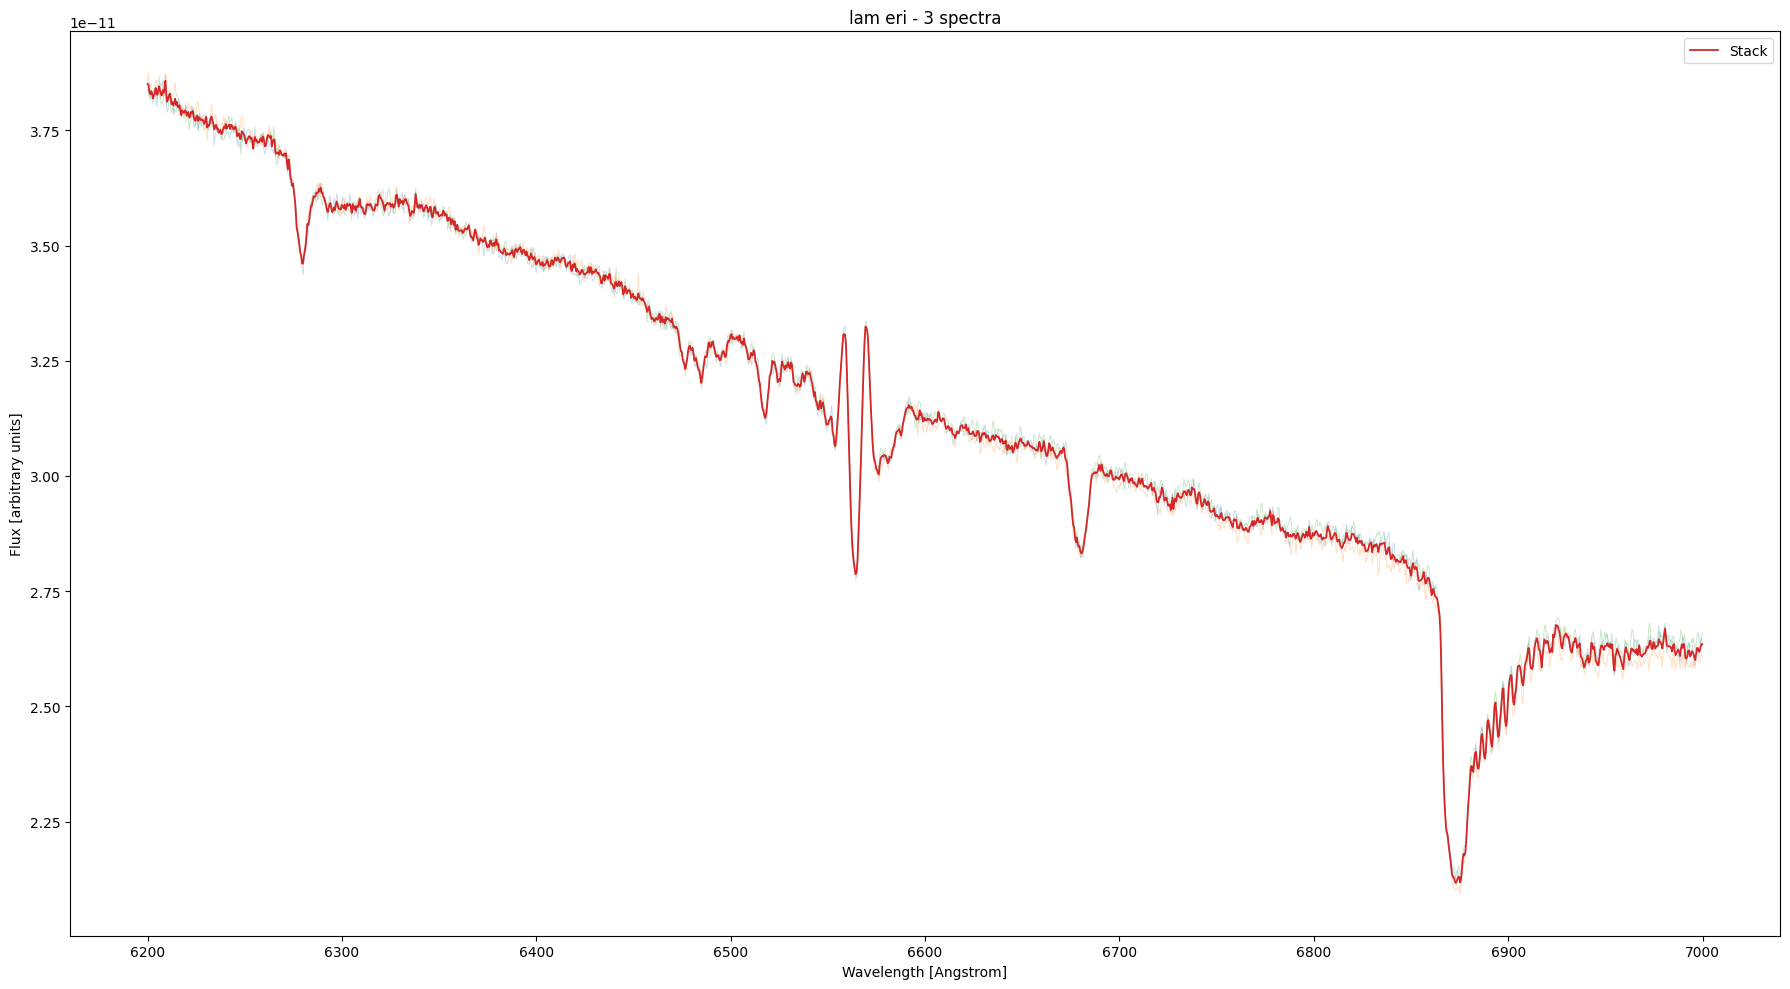

OBJNAME = 'lam eri '           / Object name                                    
EQUINOX =               2000.0 / Coordinate equinox                             
RADECSYS= 'FK5     '           / Coordinate reference frame                     
DATE-OBS= '2025-11-14T09:09:43.300' / Start of first exposure [UTC]             
DATE-END= '2025-11-14T09:12:31.360' / End of last exposure [UTC]                
EXPTIME =   168.05999999999787 / First start to last end [s]                    
EXPTIME2=                   90 / Summed CCD integration time [s]                
NCOMBINE=                    3 / Number of combined spectra                     
BSS_SITE= 'Winer Observatory'  / Observation site                               
OBSERVER= 'Joshua Marine'      / Spectrum author(s), comma delimited            
TELESCOP= 'CDK20   '           / Telescope                                      
INSTRUME= 'H-alpha grism'      / Spectrograph                                   
DETNAM  = 'ASI6200MM'       

In [257]:

plt.figure(figsize=(18, 10))
for spec_flux in stack["interpolated_flux"]:
    plt.plot(stack["wave"], spec_flux, alpha=0.25, linewidth=0.7)
plt.plot(stack["wave"], stack["flux"], linewidth=1.3, label="Stack")
plt.xlabel("Wavelength [Angstrom]")
# plt.ylabel(bess_header.get("BUNIT", "Flux"))
plt.ylabel("Flux [arbitrary units]")
plt.title(f"{bess_header['OBJNAME']} - {len(stack['spectra'])} spectra")
plt.legend()
plt.tight_layout()
plt.show()

print(repr(bess_header))



## Notes on keyword translation

The output file is built from a new header rather than by deleting cards from an internal RLMT header.

| RLMT/internal source | BeSS output |
|---|---|
| `BLKNAME` | `OBJNAME` |
| `TELRA`, `TELDEC` | `RA`, `DEC`, plus `EQUINOX=2000` and `RADECSYS=FK5` |
| `OBSLAT`, `OBSLONG`, `OBSELEV` | `BSS_LAT`, `BSS_LONG`, `BSS_ELEV` |
| `TELESCOP`, `INSTRUME`, `DETNAM` | retained as standard BeSS equipment descriptors |
| `SPEC_RES` | optional `BSS_ITRP`
| pipeline heliocentric calculation | `BSS_RQVH` only; `BSS_VHEL=0` because wavelengths remain uncorrected |
| pipeline processing state | `BSS_TELL`, `BSS_COSM`, and `BSS_NORM` |

Internal diagnostic and calibration-provenance cards such as `FWHM`, `TELLPIX`, `TELLFAIL`, `CALBIN`, `CAL00`, and `FALLBK` are deliberately omitted from the BeSS export.
